In [1]:
# Install required libraries
!pip install iterative-stratification --quiet

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Text processing
import re
import string
from collections import Counter
from wordcloud import WordCloud

# Ml libraries

# крос валидация с сохранением процентного соотношения классов
from sklearn.model_selection import StratifiedKFold
# Tf-idf кодировщик
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
# обертка для задач многоклассовой (у одного объекта несколько меток)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
# утилита для вывода подробного отчета о качестве классификации, матрица ошибок классификации
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning

import torch
# модуль для создания нейронок
import torch.nn as nn
# функциональный интерфейс
import torch.nn.functional as F
# классы для эффективной загрцзки и обработки данных
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_scheduler
from torch.optim import AdamW
# управление предупреждениями
from transformers import logging
logging.set_verbosity_error()


In [3]:
# Visualization
from sklearn.metrics import roc_curve, precision_recall_curve
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
# Set reproducibility - настройка воспроизводимости

# Без фиксации seed каждый запуск - разные результаты
def set_seed(seed=42):
  """Set seed for reproducibility"""
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.bacnhmark = False

set_seed(42)

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device {device}')

# Информация о GPU
if torch.cuda.is_available():
  print(f'GPU: {torch.cuda.get_device_name(0)}')
  print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')



Device cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Dataset
import zipfile

zip_file_path_1 = '/content/drive/MyDrive/Machine learning/datasets/sample_submission.csv.zip'
zip_file_path_2 = '/content/drive/MyDrive/Machine learning/datasets/test.csv.zip'
zip_file_path_3 = '/content/drive/MyDrive/Machine learning/datasets/train.csv.zip'

file_name_1 = 'sample_submission.csv'
file_name_2 = 'test.csv'
file_name_3 = 'train.csv'

with zipfile.ZipFile(zip_file_path_1) as zf:
    with zf.open(file_name_1) as f:
      sample_submission = pd.read_csv(f)

with zipfile.ZipFile(zip_file_path_2) as zf:
    with zf.open(file_name_2) as f:
      test_df = pd.read_csv(f)

with zipfile.ZipFile(zip_file_path_3) as zf:
    with zf.open(file_name_3) as f:
      train_df = pd.read_csv(f)


In [7]:
train_df.head(2)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0


In [8]:
# Define target columns
TARGET_COLUMNS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("=== DATASET SHAPES ===")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Submission: {sample_submission.shape}")

print("\n=== TRAIN DATASET INFO ===")
print(train_df.info())
print(f"\nColumns: {list(train_df.columns)}")

print("\n=== MISSING VALUES ===")
print("Train missing values:")
print(train_df.isnull().sum())
print("\nTest missing values:")
print(test_df.isnull().sum())

print("\n=== TARGET DISTRIBUTION ===")
target_counts = train_df[TARGET_COLUMNS].sum()
print(target_counts)
print(f"\nTotal comments: {len(train_df)}")
print(f"Percentage of toxic comments:")
for col in TARGET_COLUMNS:
    pct = (train_df[col].sum() / len(train_df)) * 100
    print(f"  {col}: {pct:.2f}%")

print(train_df[train_df.toxic == 1].head())


=== DATASET SHAPES ===
Train: (159571, 8)
Test: (153164, 2)
Submission: (153164, 7)

=== TRAIN DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None

Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

=== MISSING VALUES ===
Train missing values:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           

=== TEXT LENGTH ANALYSIS ===
Train text length stats:
count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: text_length, dtype: float64

Test text length stats:
count    153164.000000
mean        364.875121
std         592.492099
min           1.000000
25%          79.000000
50%         180.000000
75%         392.000000
max        5000.000000
Name: text_length, dtype: float64


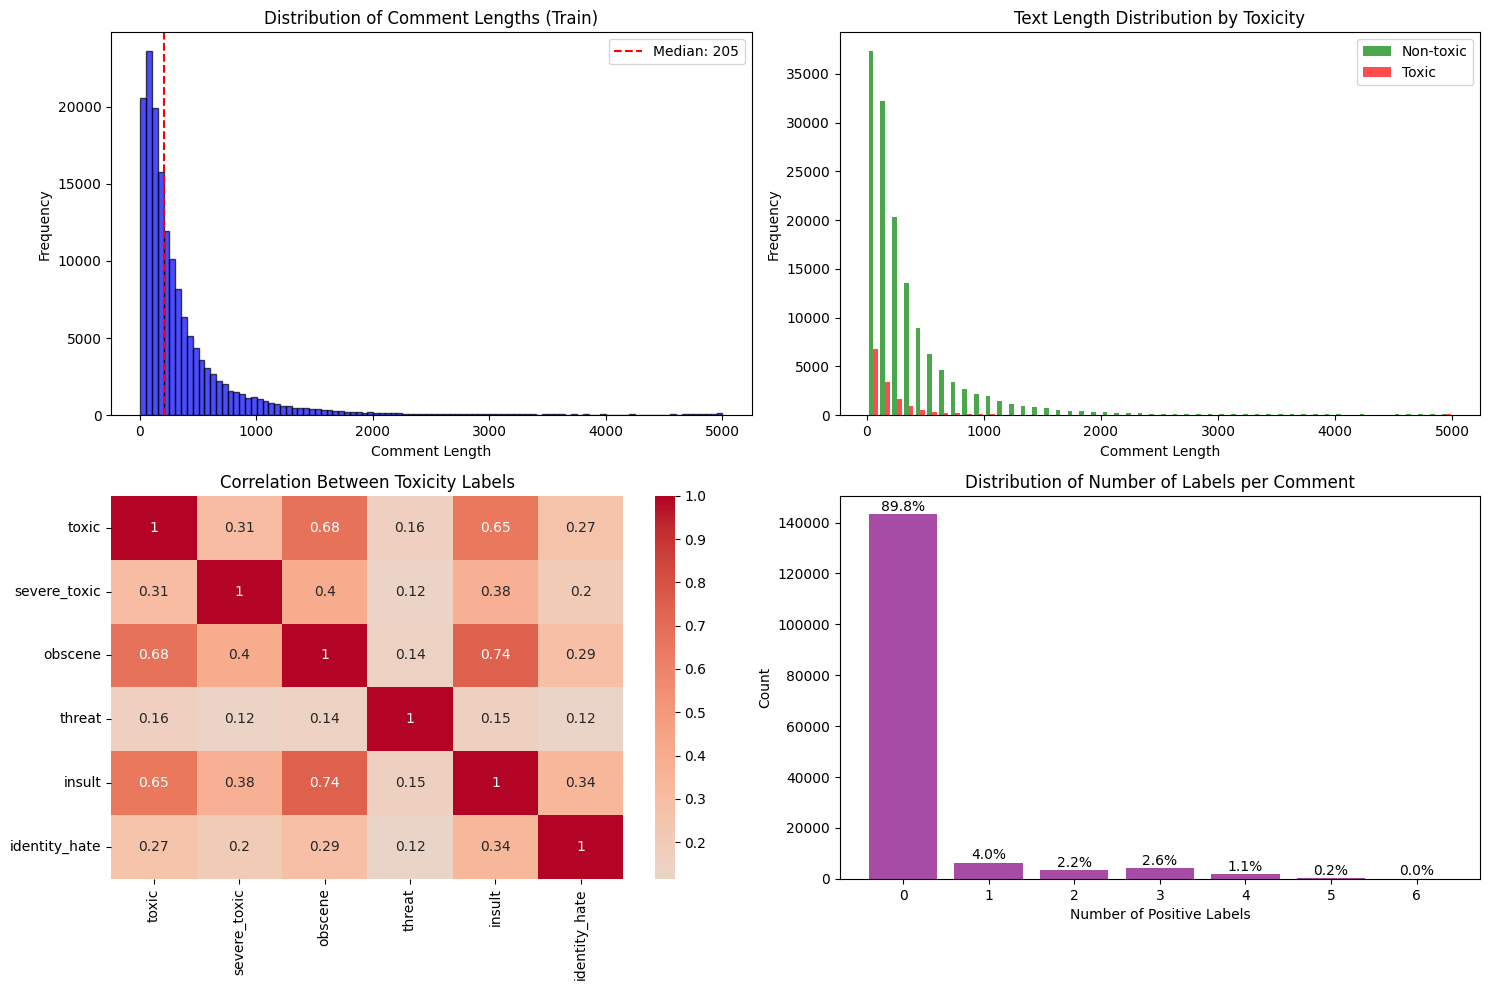

In [9]:
# === TEXT LENGTH ANALYSIS ===
print("=== TEXT LENGTH ANALYSIS ===")
# Модели имеют ограничение на длину входной последовательности
# Важно исследовать длину последовательности для выбора стратегии
train_df['text_length'] = train_df['comment_text'].str.len()
test_df['text_length'] = test_df['comment_text'].str.len()

print(f"Train text length stats:")
print(train_df['text_length'].describe())
print(f"\nTest text length stats:")
print(test_df['text_length'].describe())

# Visualization of text lengths
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall length distribution
axes[0,0].hist(train_df['text_length'], bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('Distribution of Comment Lengths (Train)')
axes[0,0].set_xlabel('Comment Length')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(train_df['text_length'].median(), color='red', linestyle='--',
                  label=f'Median: {train_df["text_length"].median():.0f}')
axes[0,0].legend()

# Распределение по токсичности
toxic_lengths = train_df[train_df['toxic']==1]['text_length']
non_toxic_lengths = train_df[train_df['toxic']==0]['text_length']

axes[0,1].hist([non_toxic_lengths, toxic_lengths], bins=50, alpha=0.7,
               label=['Non-toxic', 'Toxic'], color=['green', 'red'])
axes[0,1].set_title('Text Length Distribution by Toxicity')
axes[0,1].set_xlabel('Comment Length')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# === CLASS CORRELATION ANALYSIS ===
correlation_matrix = train_df[TARGET_COLUMNS].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,0])
axes[1,0].set_title('Correlation Between Toxicity Labels')

# === CO-OCCURRENCE ANALYSIS ===
# Count samples with multiple labels
multi_label_counts = train_df[TARGET_COLUMNS].sum(axis=1).value_counts().sort_index()
axes[1,1].bar(multi_label_counts.index, multi_label_counts.values, color='purple', alpha=0.7)
axes[1,1].set_title('Distribution of Number of Labels per Comment')
axes[1,1].set_xlabel('Number of Positive Labels')
axes[1,1].set_ylabel('Count')

# Add percentage labels
total = len(train_df)
for i, v in enumerate(multi_label_counts.values):
    axes[1,1].text(multi_label_counts.index[i], v + 100, f'{v/total*100:.1f}%',
                   ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [10]:
# === TEXT PREPROCESSING FUNCTIONS ===

def clean_text_basic(text):
  """Basic text cleaning for traditional ML models"""
  if pd.isna(text):
    return ""

  # Convert to lowercase
  text = str(text).lower()

  # Remove newlines and extra spaces
  text = re.sub(r'\n', ' ', text)
  text = re.sub(r'\s+', ' ', text)

  #  Remove URLs
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

  # Remove user mentions and special characters
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', ' ', text)

  return text.strip()

def clean_text_transformer(text):
  """Light cleaning for transformer models (they handle raw text better)"""
  # Модели вроде BERT лучше сохраняют контекст при минимальной очистке
  if pd.isna(text):
    return ''

  # Convert to string and basic cleaning
  text = str(text)

  # Remove excessive newlines and spaces
  text = re.sub(r'\n+', ' ', text)
  text = re.sub(r'\s+', ' ', text)

  return text.strip()



# Apply preprocessing
print("=== PREPROCESSING TEXT ===")
print("Applying basic cleaning...")
train_df['comment_text_clean'] = train_df['comment_text'].apply(clean_text_basic)
test_df['comment_text_clean'] = test_df['comment_text'].apply(clean_text_basic)

print("Applying transformer-friendly cleaning...")
train_df['comment_text_transformer'] = train_df['comment_text'].apply(clean_text_transformer)
test_df['comment_text_transformer'] = test_df['comment_text'].apply(clean_text_transformer)

# Show examples of cleaning
print("\n=== CLEANING EXAMPLES ===")
examples = train_df.sample(3, random_state=42)
for idx, row in examples.iterrows():
    print(f"\nOriginal: {row['comment_text'][:100]}...")
    print(f"Basic cleaned: {row['comment_text_clean'][:100]}...")
    print(f"Transformer cleaned: {row['comment_text_transformer'][:100]}...")
    print("-" * 80)



=== PREPROCESSING TEXT ===
Applying basic cleaning...
Applying transformer-friendly cleaning...

=== CLEANING EXAMPLES ===

Original: Geez, are you forgetful!  We've already discussed why Marx  was  not an anarchist, i.e. he wanted to...
Basic cleaned: geez, are you forgetful! we ve already discussed why marx was not an anarchist, i.e. he wanted to us...
Transformer cleaned: Geez, are you forgetful! We've already discussed why Marx was not an anarchist, i.e. he wanted to us...
--------------------------------------------------------------------------------

Original: Carioca RFA 

Thanks for your support on my request for adminship.

The final outcome was (31/4/1), ...
Basic cleaned: carioca rfa thanks for your support on my request for adminship. the final outcome was  31 4 1 , so ...
Transformer cleaned: Carioca RFA Thanks for your support on my request for adminship. The final outcome was (31/4/1), so ...
------------------------------------------------------------------------------

In [11]:

# === STRATIFIED K-FOLD CREATION ===
print("\n=== CREATING STRATIFIED FOLDS ===")

# Install iterative-stratification if not available
try:
    from iterstrat import ml_stratifiers
except ImportError:
    print("Installing iterative-stratification...")
    !pip install iterative-stratification --quiet
    from iterstrat import ml_stratifiers


# Create stratified folds for multi-label
def create_folds(df, n_folds=5, random_state=42):
    """Create stratified folds for multi-label classification"""
    df_folds = df.copy()

    # Use iterative stratification for multi-label
    mskf = ml_stratifiers.MultilabelStratifiedKFold(
        n_splits=n_folds, shuffle=True, random_state=random_state
    )

    df_folds['fold'] = -1
    for fold, (_, val_idx) in enumerate(mskf.split(df_folds, df_folds[TARGET_COLUMNS])):
        df_folds.loc[val_idx, 'fold'] = fold

    return df_folds


# Create folds
train_df = create_folds(train_df, n_folds=5)

# Verify fold distribution
print("Fold distribution:")
print(train_df['fold'].value_counts().sort_index())

print("\nTarget distribution per fold:")
for fold in range(5):
    fold_data = train_df[train_df['fold'] == fold]
    print(f"\nFold {fold}:")
    for col in TARGET_COLUMNS:
        pct = (fold_data[col].sum() / len(fold_data)) * 100
        print(f"  {col}: {pct:.2f}%")


# === TEXT STATISTICS AFTER CLEANING ===
print("\n=== TEXT STATISTICS AFTER CLEANING ===")
print("Basic cleaned text length stats:")
print(train_df['comment_text_clean'].str.len().describe())

print("\nTransformer cleaned text length stats:")
print(train_df['comment_text_transformer'].str.len().describe())

# Check for any empty texts after cleaning
empty_clean = (train_df['comment_text_clean'].str.len() == 0).sum()
empty_transformer = (train_df['comment_text_transformer'].str.len() == 0).sum()
print(f"\nEmpty texts after basic cleaning: {empty_clean}")
print(f"Empty texts after transformer cleaning: {empty_transformer}")


=== CREATING STRATIFIED FOLDS ===
Fold distribution:
fold
0    31914
1    31915
2    31914
3    31914
4    31914
Name: count, dtype: int64

Target distribution per fold:

Fold 0:
  toxic: 9.59%
  severe_toxic: 1.00%
  obscene: 5.30%
  threat: 0.30%
  insult: 4.94%
  identity_hate: 0.88%

Fold 1:
  toxic: 9.58%
  severe_toxic: 1.00%
  obscene: 5.30%
  threat: 0.30%
  insult: 4.94%
  identity_hate: 0.88%

Fold 2:
  toxic: 9.59%
  severe_toxic: 1.00%
  obscene: 5.30%
  threat: 0.30%
  insult: 4.94%
  identity_hate: 0.88%

Fold 3:
  toxic: 9.58%
  severe_toxic: 1.00%
  obscene: 5.29%
  threat: 0.30%
  insult: 4.94%
  identity_hate: 0.88%

Fold 4:
  toxic: 9.59%
  severe_toxic: 1.00%
  obscene: 5.30%
  threat: 0.30%
  insult: 4.94%
  identity_hate: 0.88%

=== TEXT STATISTICS AFTER CLEANING ===
Basic cleaned text length stats:
count    159571.00000
mean        385.96307
std         581.59400
min           0.00000
25%          92.00000
50%         200.00000
75%         427.00000
max        5

In [12]:
# === BASELINE MODEL: TF-IDF + LOGISTIC REGRESSION ===
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline

print("=== BUILDING BASELINE MODEL ===")

def train_baseline_model(fold=0):
  """Train baseline model on specific fold"""

  # Get fold data
  train_idx = train_df[train_df['fold'] != fold].index
  val_idx = train_df[train_df['fold'] == fold].index

  X_train = train_df.loc[train_idx, 'comment_text_clean']
  X_val = train_df.loc[val_idx, 'comment_text_clean']
  y_train = train_df.loc[train_idx, TARGET_COLUMNS]
  y_val = train_df.loc[val_idx, TARGET_COLUMNS]

  print(f'Fold {fold}: Train size: {len(X_train)}, Val size: {len(X_val)}')

  # TF-IDF vectorize
  tfidf = TfidfVectorizer(
      max_features=50000,
      ngram_range=(1,2),
      min_df=3,
      max_df=0.9,
      strip_accents='unicode',
      use_idf=True,
      smooth_idf=True,
      sublinear_tf=True,
      stop_words='english'
  )

  # Multi-output classifier with Logistic Regression
  model = MultiOutputClassifier(
      LogisticRegression(
          C=1.0, # обратный коэф. регуляризации
          max_iter=1000,
          random_state=42,
          n_jobs=-1

      )
  )

  # Create pipeline
  pipeline = Pipeline([
      ('tfidf', tfidf),
      ('classifier', model)
  ])

  # train model
  print(f"Training baseline model for fold {fold}...")
  pipeline.fit(X_train, y_train)

  # Predict probabilities
  train_preds = pipeline.predict_proba(X_train)
  val_preds = pipeline.predict_proba(X_val)

  # Extract probabilities for positive class (index 1)
  train_probs = np.column_stack([pred[:, 1] for pred in train_preds])
  val_probs = np.column_stack([pred[:, 1] for pred in val_preds])

  # Calculate metrics
  train_auc = roc_auc_score(y_train, train_probs, average='macro')
  val_auc = roc_auc_score(y_val, val_probs, average='macro')

  # Individual class AUCs
  train_aucs = roc_auc_score(y_train, train_probs, average=None)
  val_aucs = roc_auc_score(y_val, val_probs, average=None)
  print(f"Fold {fold} Results:")
  print(f"  Train AUC (macro): {train_auc:.4f}")
  print(f"  Val AUC (macro): {val_auc:.4f}")
  print(f"  Individual val AUCs:")
  for i, col in enumerate(TARGET_COLUMNS):
    print(f"    {col}: {val_aucs[i]:.4f}")

  return pipeline, val_probs, val_aucs, val_auc



=== BUILDING BASELINE MODEL ===


In [13]:
# === CROSS-VALIDATION ===
print("=== RUNNING CROSS-VALIDATION ===")

baseline_models = [] # для сохраниения всех 5 моделей
all_val_preds = []   # для вероятностей на валидации
all_val_aucs = []    # для AUC по каждому классу
all_macro_aucs = []

for fold in range(5):
    model, val_preds, val_aucs, macro_auc = train_baseline_model(fold)
    baseline_models.append(model)
    all_val_preds.append(val_preds)
    all_val_aucs.append(val_aucs)
    all_macro_aucs.append(macro_auc)
    print("-" * 50)

=== RUNNING CROSS-VALIDATION ===
Fold 0: Train size: 127657, Val size: 31914
Training baseline model for fold 0...
Fold 0 Results:
  Train AUC (macro): 0.9893
  Val AUC (macro): 0.9768
  Individual val AUCs:
    toxic: 0.9682
    severe_toxic: 0.9850
    obscene: 0.9844
    threat: 0.9791
    insult: 0.9735
    identity_hate: 0.9703
--------------------------------------------------
Fold 1: Train size: 127656, Val size: 31915
Training baseline model for fold 1...
Fold 1 Results:
  Train AUC (macro): 0.9885
  Val AUC (macro): 0.9779
  Individual val AUCs:
    toxic: 0.9695
    severe_toxic: 0.9848
    obscene: 0.9855
    threat: 0.9785
    insult: 0.9766
    identity_hate: 0.9727
--------------------------------------------------
Fold 2: Train size: 127657, Val size: 31914
Training baseline model for fold 2...
Fold 2 Results:
  Train AUC (macro): 0.9888
  Val AUC (macro): 0.9796
  Individual val AUCs:
    toxic: 0.9711
    severe_toxic: 0.9844
    obscene: 0.9864
    threat: 0.9755
    

In [14]:
# === FINAL RESULTS ===
print("=== BASELINE CROSS-VALIDATION RESULTS ===")

# Average AUCs across folds
mean_aucs = np.mean(all_val_aucs, axis=0)
std_aucs = np.std(all_val_aucs, axis=0)

print("Individual class performance:")
for i, col in enumerate(TARGET_COLUMNS):
    print(f"  {col}: {mean_aucs[i]:.4f} ± {std_aucs[i]:.4f}")

mean_macro_auc = np.mean(all_macro_aucs)
std_macro_auc = np.std(all_macro_aucs)
print(f"\nMacro AUC: {mean_macro_auc:.4f} ± {std_macro_auc:.4f}")

# === PREDICTION ON TEST SET ===
print("\n=== GENERATING TEST PREDICTIONS ===")

# Train final model on full training data
print("Training final model on full training data...")
final_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    strip_accents='unicode',
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=True,
    stop_words='english'
)

final_model = MultiOutputClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
)

final_pipeline = Pipeline([
    ('tfidf', final_tfidf),
    ('classifier', final_model)
])

# Fit on full training data
X_full = train_df['comment_text_clean']
y_full = train_df[TARGET_COLUMNS]

final_pipeline.fit(X_full, y_full)

# Predict on test set
print("Generating test predictions...")
test_preds = final_pipeline.predict_proba(test_df['comment_text_clean'])
test_probs = np.column_stack([pred[:, 1] for pred in test_preds])

# Create baseline submission
baseline_submission = sample_submission.copy()
baseline_submission[TARGET_COLUMNS] = test_probs

print("Baseline model completed!")
print(f"Test predictions shape: {test_probs.shape}")
print(f"Sample predictions:")
print(baseline_submission.head())

# Save baseline results
baseline_results = {
    'cv_macro_auc': mean_macro_auc,
    'cv_macro_auc_std': std_macro_auc,
    'individual_aucs': dict(zip(TARGET_COLUMNS, mean_aucs)),
    'individual_aucs_std': dict(zip(TARGET_COLUMNS, std_aucs))
}

print(f"\nBaseline Results Summary:")
print(f"CV Macro AUC: {baseline_results['cv_macro_auc']:.4f}")
print("Individual class AUCs:", {k: f"{v:.4f}" for k, v in baseline_results['individual_aucs'].items()})

=== BASELINE CROSS-VALIDATION RESULTS ===
Individual class performance:
  toxic: 0.9703 ± 0.0016
  severe_toxic: 0.9853 ± 0.0014
  obscene: 0.9853 ± 0.0007
  threat: 0.9800 ± 0.0036
  insult: 0.9767 ± 0.0026
  identity_hate: 0.9747 ± 0.0031

Macro AUC: 0.9787 ± 0.0013

=== GENERATING TEST PREDICTIONS ===
Training final model on full training data...
Generating test predictions...
Baseline model completed!
Test predictions shape: (153164, 6)
Sample predictions:
                 id     toxic  severe_toxic   obscene    threat    insult  \
0  00001cee341fdb12  0.995636      0.098622  0.992414  0.026917  0.881429   
1  0000247867823ef7  0.007315      0.004990  0.004650  0.001660  0.007838   
2  00013b17ad220c46  0.010527      0.003394  0.004914  0.000865  0.005937   
3  00017563c3f7919a  0.006550      0.003841  0.005069  0.001164  0.005002   
4  00017695ad8997eb  0.050611      0.004017  0.012928  0.001491  0.020218   

   identity_hate  
0       0.198884  
1       0.003212  
2       0.00181

In [15]:
def predict_comment_toxicity(comment_text, model_pipeline):
    cleaned_text = clean_text_basic(comment_text)
    predictions = model_pipeline.predict_proba([cleaned_text])
    probabilities = [pred[0, 1] for pred in predictions]

    results = {}
    for i, col in enumerate(TARGET_COLUMNS):
        results[col] = probabilities[i]

    return results

def analyze_comment(comment_text):
    results = predict_comment_toxicity(comment_text, final_pipeline)
    max_prob = max(results.values())
    max_category = max(results, key=results.get)

    # Decision logic
    if max_prob > 0.9:
        decision = "BLOCK IMMEDIATELY"
        risk = "CRITICAL"
    elif max_prob > 0.7:
        decision = "MANUAL REVIEW"
        risk = "HIGH"
    elif max_prob > 0.3:
        decision = "WARN USER"
        risk = "MEDIUM"
    else:
        decision = "ALLOW"
        risk = "LOW"

    print(f"Comment: '{comment_text}'")
    print(f"Decision: {decision} ({risk})")
    print(f"Highest risk: {max_category} ({max_prob:.3f})")

    # Show breakdown for risky comments
    if max_prob > 0.3:
        breakdown = []
        for cat in TARGET_COLUMNS:
            if results[cat] > 0.2:
                breakdown.append(f"{cat}:{results[cat]*100:.0f}%")
        if breakdown:
            print(f"Breakdown: {', '.join(breakdown)}")

    # Detect toxic words
    toxic_words = ['stupid', 'idiot', 'hate', 'kill', 'die', 'moron', 'fool', 'damn', 'hell', 'shit', 'fuck', 'garbage', 'shut']
    found_words = [word for word in toxic_words if word in comment_text.lower()]
    if found_words:
        print(f"Detected words: {', '.join(found_words)}")

    print("-" * 50)
    return results

In [16]:
# === YOUR COMMENTS TESTING ===

print("=== TESTING NEW COMMENTS ===")

your_comments = [
    "This article is really helpful and informative",
    "I disagree with this approach completely",
    "fuCK, what a bunch of nonsense from these people",
    "You guys are absolutely clueless about everything",
    "This is total, fucking garbage and waste of time",
    "ur such a looser and dont know anything"
]

for i, comment in enumerate(your_comments, 1):
    print(f"\nComment {i}:")
    analyze_comment(comment)

# === BATCH RESULTS SUMMARY ===

print("\n=== BATCH SUMMARY ===")
print("Quick overview of your comments:")

for i, comment in enumerate(your_comments, 1):
    results = predict_comment_toxicity(comment, final_pipeline)
    max_prob = max(results.values())

    if max_prob > 0.7:
        status = "TOXIC"
    elif max_prob > 0.3:
        status = "RISKY"
    else:
        status = "SAFE"

    print(f"{i}. '{comment[:40]}...' -> {status} ({max_prob:.2f})")

print(f"\nModel performance: CV AUC {baseline_results['cv_macro_auc']:.3f}")

=== TESTING NEW COMMENTS ===

Comment 1:
Comment: 'This article is really helpful and informative'
Decision: ALLOW (LOW)
Highest risk: toxic (0.025)
--------------------------------------------------

Comment 2:
Comment: 'I disagree with this approach completely'
Decision: ALLOW (LOW)
Highest risk: toxic (0.017)
--------------------------------------------------

Comment 3:
Comment: 'fuCK, what a bunch of nonsense from these people'
Decision: BLOCK IMMEDIATELY (CRITICAL)
Highest risk: toxic (1.000)
Breakdown: toxic:100%, severe_toxic:20%, obscene:100%, insult:96%
Detected words: fuck
--------------------------------------------------

Comment 4:
Comment: 'You guys are absolutely clueless about everything'
Decision: ALLOW (LOW)
Highest risk: toxic (0.222)
--------------------------------------------------

Comment 5:
Comment: 'This is total, fucking garbage and waste of time'
Decision: BLOCK IMMEDIATELY (CRITICAL)
Highest risk: toxic (0.998)
Breakdown: toxic:100%, obscene:98%, insult:68